In [1]:
import xscen as xs
import xarray as xr
from xscen import CONFIG
from matplotlib import pyplot as plt
import xclim as xc
import figanos.matplotlib as fg
from datetime import datetime
import cartopy.crs as ccrs
import numpy as np
import random
import glob
from matplotlib.colors import LogNorm
fg.utils.set_mpl_style('ouranos')
xs.load_config("../config/config_general.yml", "../config/config_region.yml", "../config/paths.yml")

/cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/MPI/gcc12/openmpi4/esmf/8.8.0/lib/python3.11/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


# health checks

In [7]:
# print any health checks raised
for f in np.sort(glob.glob(f"{CONFIG['DQM']}/checks/NAM-C3/*")):
    print(f.split("/")[-1])
    ds= xr.open_zarr(f)
    for var in ds.data_vars:
        if ds[var].values:
            print(var, ds[var].values)
    print('')

CMIP6_CORDEX_CNRM-ESM2-1_r1i1p1f2_OURANOS_CRCM5-SN_ssp370_r1_NAM-12+CaSRv32+NAM-C3_checks.zarr.zip
tasmin_temperature_extremely_low True

CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12+CaSRv32+NAM-C3_checks.zarr.zip
pr_very_large_precipitation_events True
tasmin_temperature_extremely_low True

CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12+CaSRv32+NAM-C3_checks.zarr.zip
pr_very_large_precipitation_events True
tasmin_temperature_extremely_low True

CMIP6_CORDEX_NorESM2-MM_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12+CaSRv32+NAM-C3_checks.zarr.zip
pr_very_large_precipitation_events True
tasmin_temperature_extremely_low True



In [2]:
for var in ['tasmin', 'pr']:
    print(var)
    for f in np.sort(glob.glob(f"{CONFIG['DQM']}staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/*/*/*/*/day/*/*{var}*")):
        print(f)
        ds=xr.open_zarr(f, decode_timedelta=False)
        if 'tasmin' in ds:
            m=f"{ds.tasmin.min().values} {ds.tasmin.attrs['units']}"
            print(m, xc.core.units.convert_units_to(m, 'degC'),'degC')
        if 'pr' in ds:
            m=f"{ds.pr.max().values} {ds.pr.attrs['units']}"
            print(m, xc.core.units.convert_units_to(m, 'mm/day', context='hydro'),'mm/day')
            
        

tasmin
/project/ctb-frigon/julavoie/ESPO/dec2025/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/CNRM-ESM2-1/r1i1p1f2/OURANOS/CRCM5-SN/day/tasmin/tasmin_day_ESPO6_v20_CaSRv32+CMIP6_CORDEX_CNRM-ESM2-1_r1i1p1f2_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1950-2100.zarr.zip
-260.125 K -533.275 degC
/project/ctb-frigon/julavoie/ESPO/dec2025/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/CanESM5/r1i1p2f1/OURANOS/CRCM5-SN/day/tasmin/tasmin_day_ESPO6_v20_CaSRv32+CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1950-2100.zarr.zip
197.09375 K -76.05624999999998 degC
/project/ctb-frigon/julavoie/ESPO/dec2025/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/MPI-ESM1-2-LR/r1i1p1f1/OURANOS/CRCM5-SN/day/tasmin/tasmin_day_ESPO6_v20_CaSRv32+CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1950-2100.zarr.zip
195.84375 K -77.30624999999998 degC
/project/ctb-frigon/julavoie/ESPO/dec2025/staging/simulation/biasadjuste

In [2]:
ds= xr.open_zarr('/project/ctb-frigon/julavoie/ESPO/dec2025/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/CNRM-ESM2-1/r1i1p1f2/OURANOS/CRCM5-SN/day/tasmin/tasmin_day_ESPO6_v20_CaSRv32+CMIP6_CORDEX_CNRM-ESM2-1_r1i1p1f2_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1950-2100.zarr.zip')
ds.where((ds.tasmin==-260.125).compute(), drop=True)

<xarray.Dataset> Size: 33B
Dimensions:       (time: 1, rlat: 1, rlon: 1)
Coordinates:
    crs           |S1 1B b''
    lat           (rlat, rlon) float32 4B 34.0
    lon           (rlat, rlon) float32 4B -119.8
  * rlat          (rlat) float32 4B -19.35
  * rlon          (rlon) float32 4B -23.88
    rotated_pole  int32 4B 1
  * time          (time) object 8B 1950-01-01 00:00:00
Data variables:
    tasmin        (time, rlat, rlon) float32 4B dask.array<chunksize=(1, 1, 1), meta=np.ndarray>
Attributes: (12/25)
    Notes:                        Regridded on the grid of CaSR v3.2, then bi...
    avertissement:                Ouranos ne donne aucune garantie, expresse ...
    cat:_data_format_:            zarr
    cat:activity:                 CORDEX
    cat:bias_adjust_institution:  Ouranos
    cat:bias_adjust_project:      ESPO6
    ...                           ...
    disclaimer:                   Ouranos make no warranty, either express or...
    history:                      [2025-12-17 20:44:55] regridded with argume...
    license:                      Creative Commons Attribution 4.0 Internatio...
    organisation:                 Groupe scénarios et services climatiques, C...
    organization:                 Scenarios and Climate Services Group, Ouran...
    version:                      v20

In [10]:
print(ds.sel(rlat=-19.35, rlon=-23.877213, time='1950-01-01').tasmin.values)

ds_tasmax= xr.open_zarr('/project/ctb-frigon/julavoie/ESPO/dec2025/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/CNRM-ESM2-1/r1i1p1f2/OURANOS/CRCM5-SN/day/tasmax/tasmax_day_ESPO6_v20_CaSRv32+CMIP6_CORDEX_CNRM-ESM2-1_r1i1p1f2_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1950-2100.zarr.zip')
ds_dtr= xr.open_zarr('/project/ctb-frigon/julavoie/ESPO/dec2025/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/CNRM-ESM2-1/r1i1p1f2/OURANOS/CRCM5-SN/day/dtr/dtr_day_ESPO6_v20_CaSRv32+CMIP6_CORDEX_CNRM-ESM2-1_r1i1p1f2_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1950-2100.zarr.zip')
print(ds_tasmax.sel(rlat=-19.35, rlon=-23.877213, time='1950-01-01').tasmax.values)
print(ds_dtr.sel(rlat=-19.35, rlon=-23.877213, time='1950-01-01').dtr.values)

print(ds_dtr.sel(rlat=-19.35, rlon=-23.877213, ).lat.values, ds_dtr.sel(rlat=-19.35, rlon=-23.877213, ).lon.values)


[-260.125]
[290.]
[550.125]
33.99979 -119.83325


In [9]:
ds_reg=xr.open_zarr('/scratch/julavoie/espo-workdir/CMIP6_CORDEX_CNRM-ESM2-1_r1i1p1f2_OURANOS_CRCM5-SN_ssp370_r1_NAM-12+NAM-C3+bC3+regridded.zarr')
ds_reg=xs.utils.unstack_fill_nan(ds_reg)
for var in ['tasmin','tasmax', 'dtr']:
    print(ds_reg.sel(rlat=-19.35, rlon=-23.877213, time='1950-01-01')[var].values)

2025-12-19 08:23:51 INFO     xscen.utils     Dataset unstacked using /project/ctb-frigon/julavoie/ESPO/dec2025/coords/coords_bC3_167x700.nc.
0.0
290.3332
290.3332


In [13]:
ds_ext=xr.open_zarr('/scratch/julavoie/espo-workdir/CMIP6_CORDEX_CNRM-ESM2-1_r1i1p1f2_OURANOS_CRCM5-SN_ssp370_r1_NAM-12+NAM-C3+extracted.zarr')
ds_ext_point=xs.spatial.subset(ds_ext, method='gridpoint',lat=33.99979, lon=-119.83325)
for var in ['tasmin','tasmax', 'dtr']:
    print(ds_ext_point[var].values)

2025-12-19 08:28:26 INFO     xscen.spatial   Loading longitude for more efficient subsetting.
2025-12-19 08:28:26 INFO     xscen.spatial   Loading latitude for more efficient subsetting.
[  0.     288.4375 289.125  ... 287.125  286.125  288.1875]
[291.0625 291.5    293.3125 ... 291.4375 289.8125 289.75  ]
[291.0625   3.0625   4.1875 ...   4.3125   3.6875   1.5625]


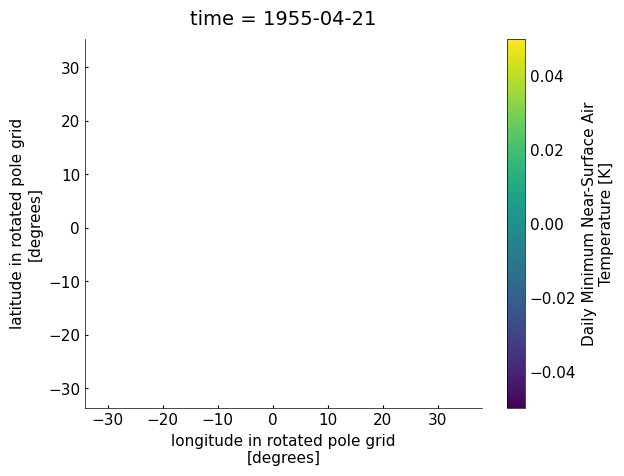

In [15]:
ds_ext.tasmin.sel(time='1955-04-21').plot()

# diagnostiques VALUE


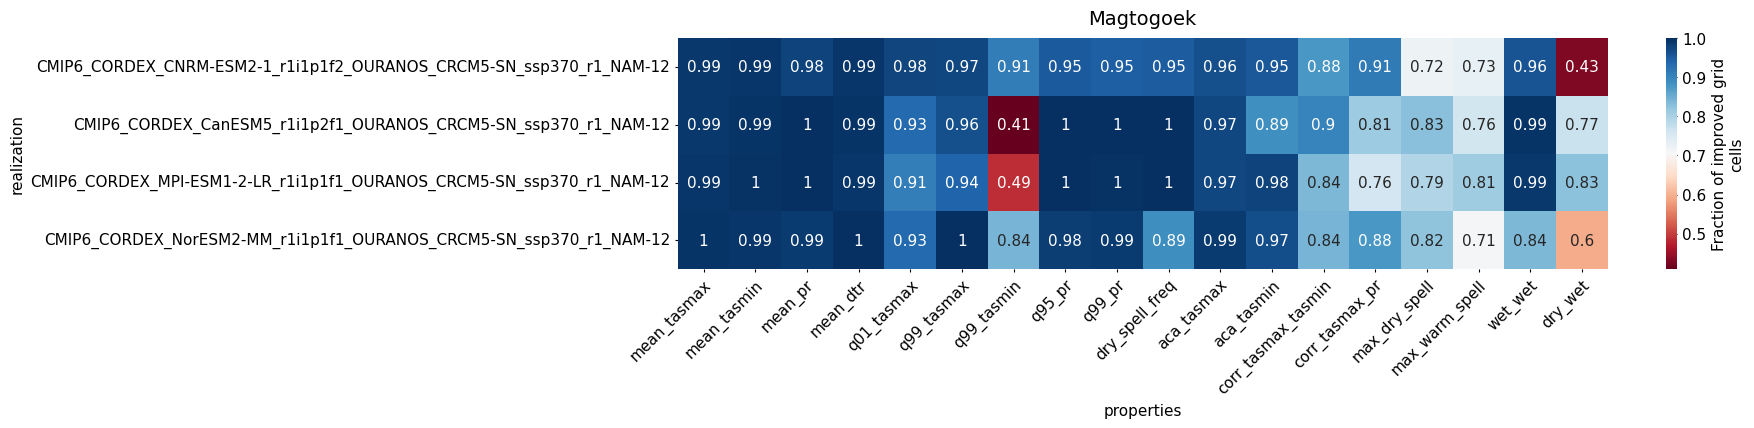

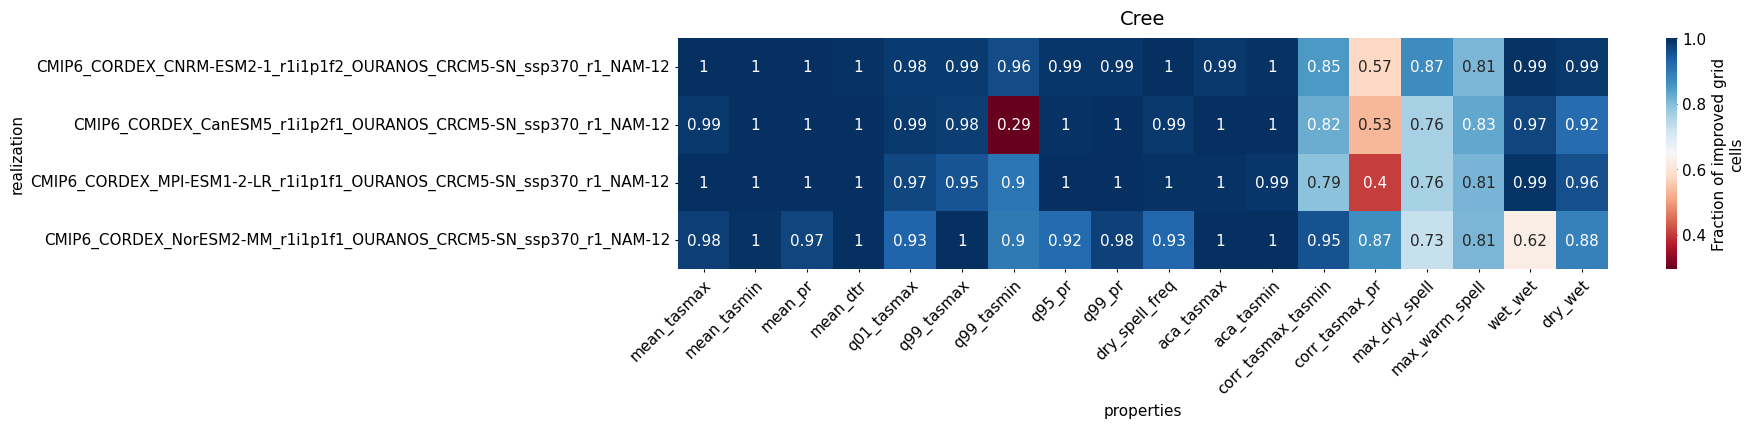

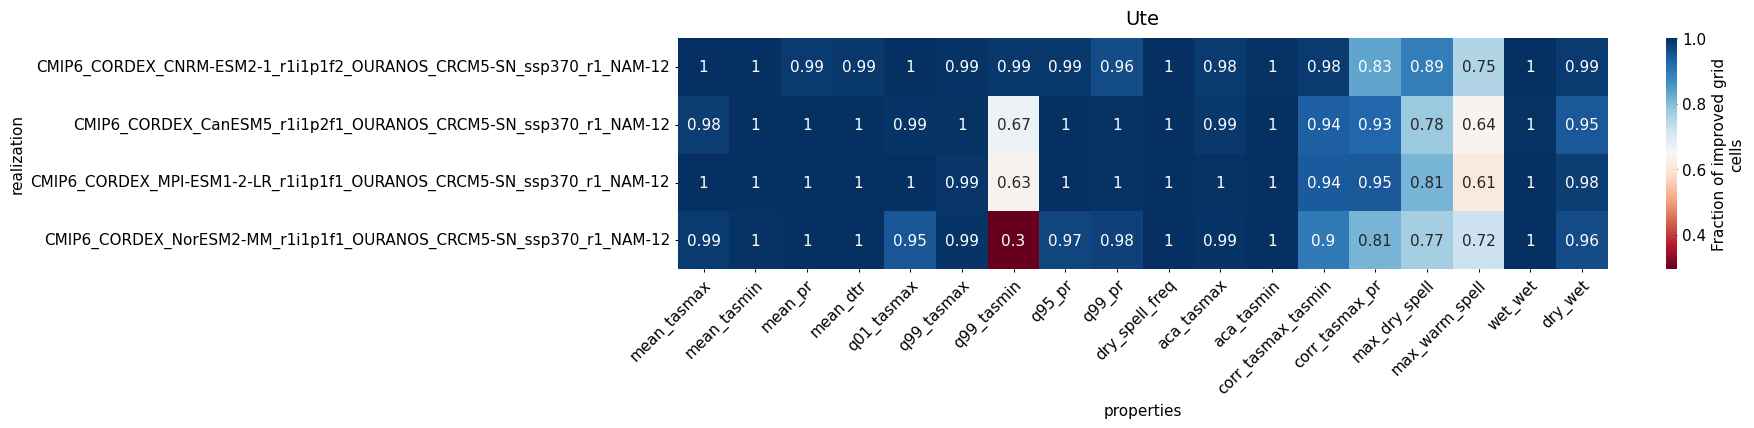

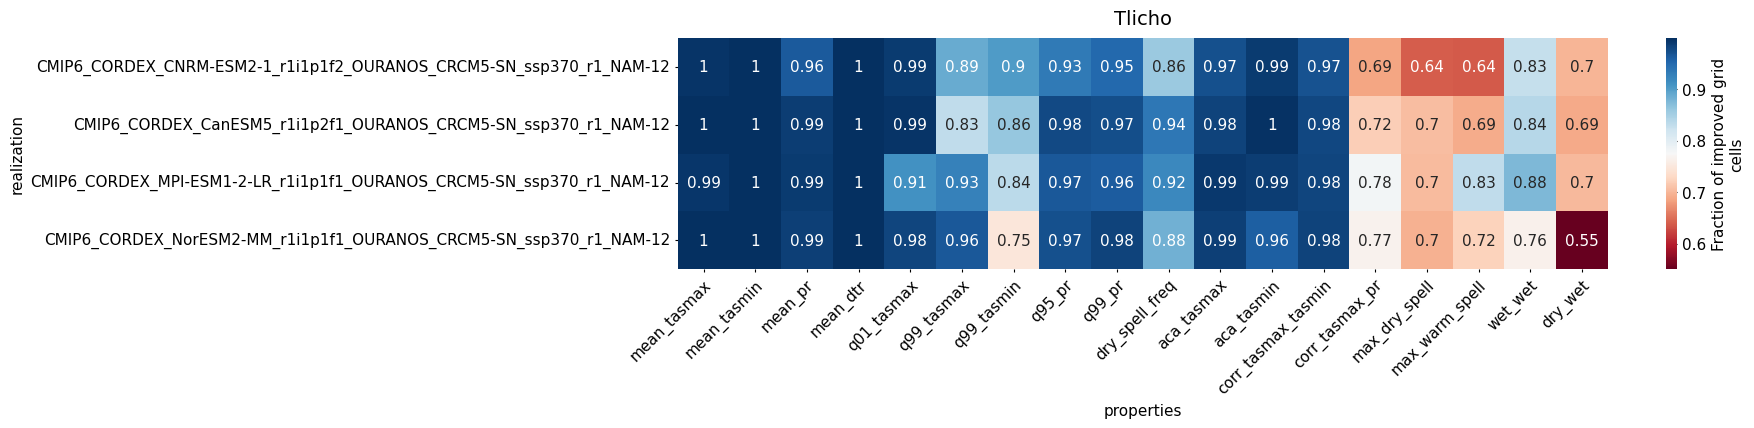

In [11]:
for r in ['Magtogoek','Cree','Ute','Tlicho']:

    imps=[]
    for f in np.sort(glob.glob(f"{CONFIG['DQM']}/diagnostics/CaSRv32/NAM-C3/{r}/CMIP6*/*imp.zarr.zip")):
        imp=xr.open_zarr(f, decode_timedelta=False)
        imp=imp.expand_dims(realization=[imp.attrs['cat:id']])
        
        imps.append(imp)

    ds_imp= xr.concat(imps, dim='realization')
    ds_imp=ds_imp.sel(properties=["mean_tasmax","mean_tasmin","mean_pr","mean_dtr","q01_tasmax","q99_tasmax","q99_tasmin","q95_pr","q99_pr","dry_spell_freq","aca_tasmax","aca_tasmin","corr_tasmax_tasmin","corr_tasmax_pr","max_dry_spell","max_warm_spell","wet_wet","dry_wet",])
    ds_imp=ds_imp.drop_vars(['rotated_pole', 'crs','quantization_info'])
    
    ax=fg.heatmap(ds_imp,plot_kw={'annot':True, }, fig_kw={'figsize':(15,3)})
    ax.set_title(r)

# plot 1 random day


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.

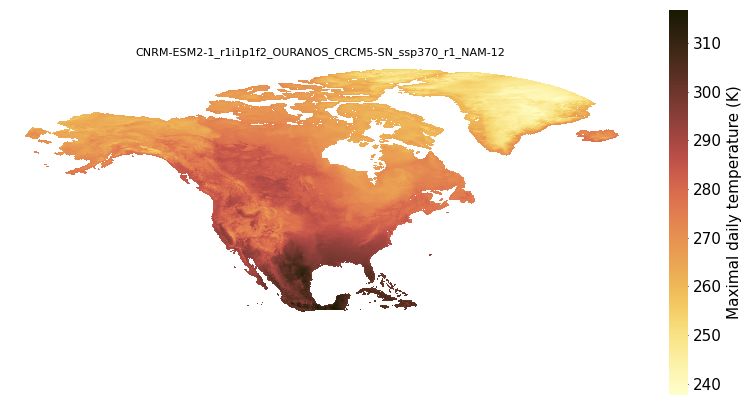

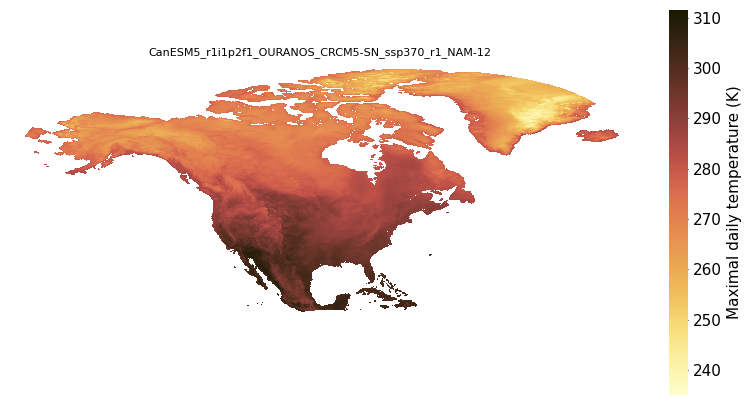

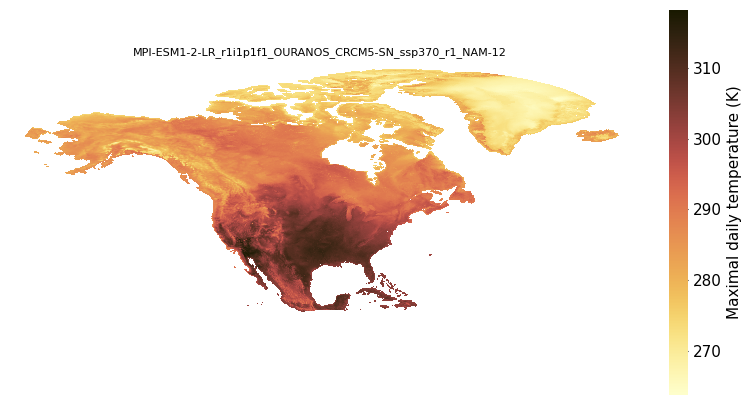

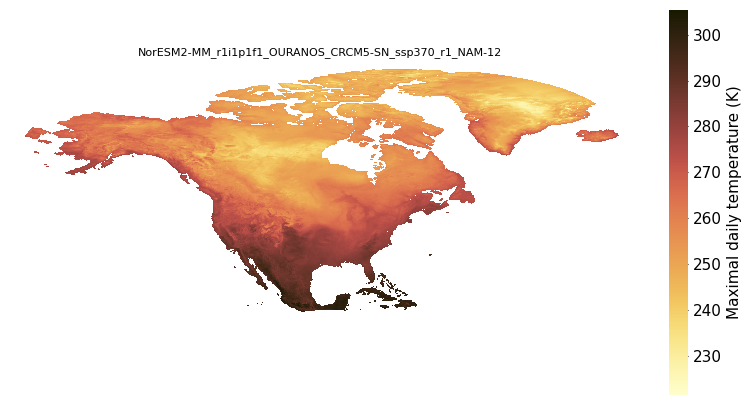

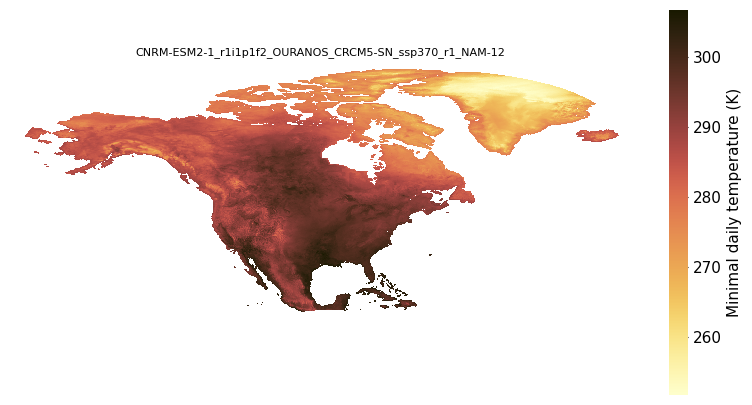

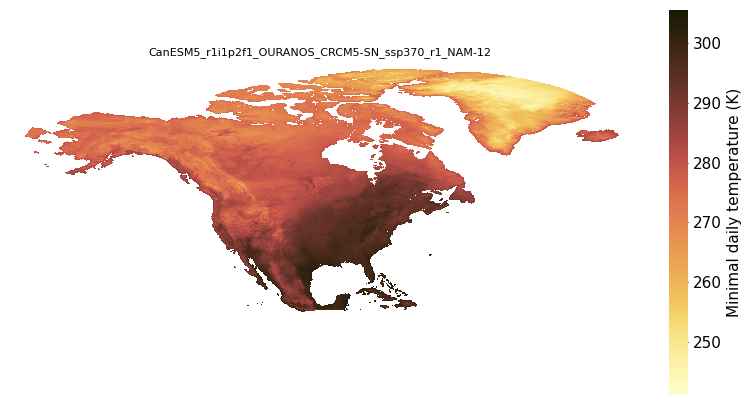

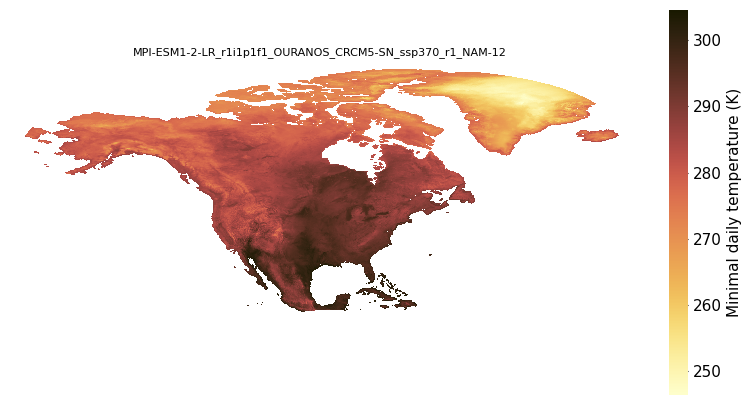

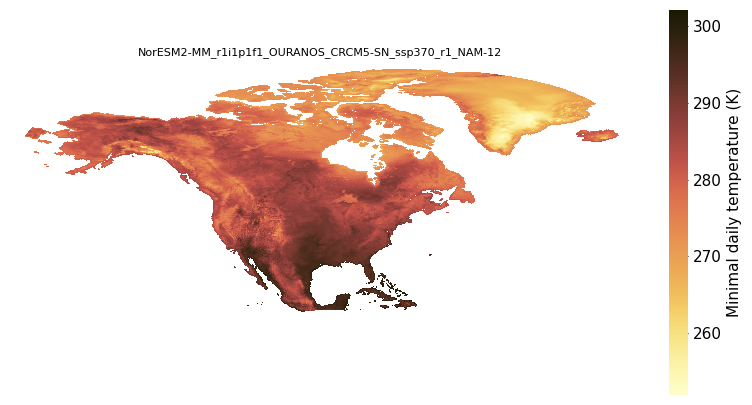

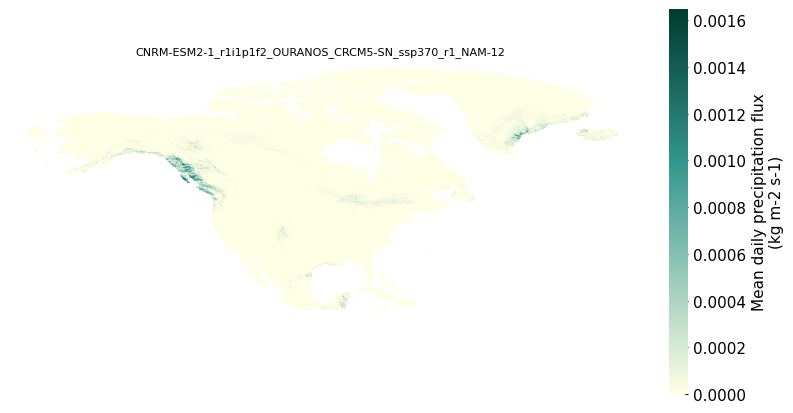

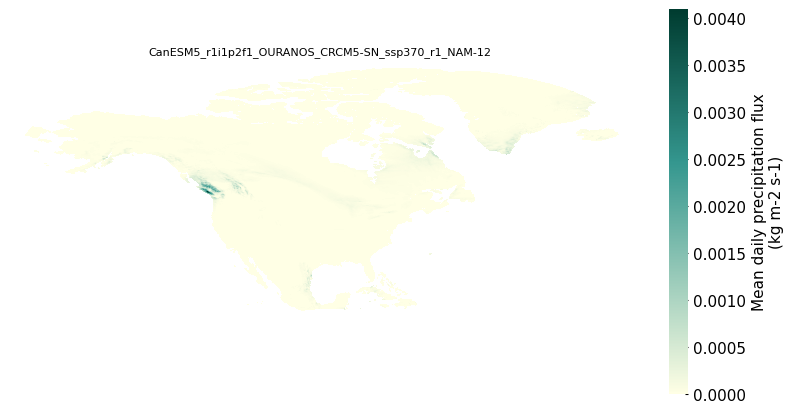

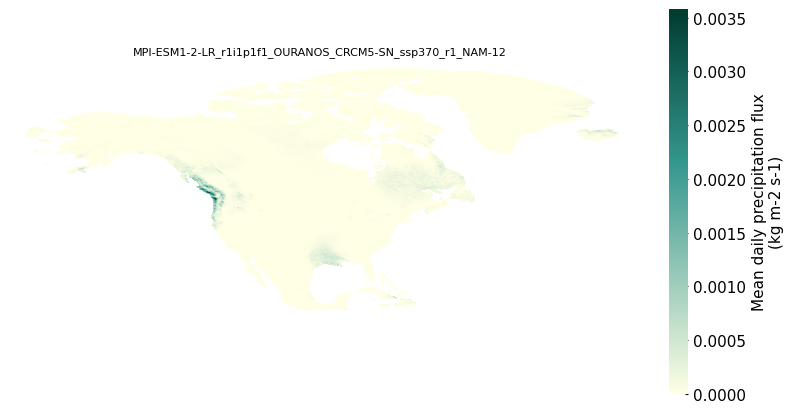

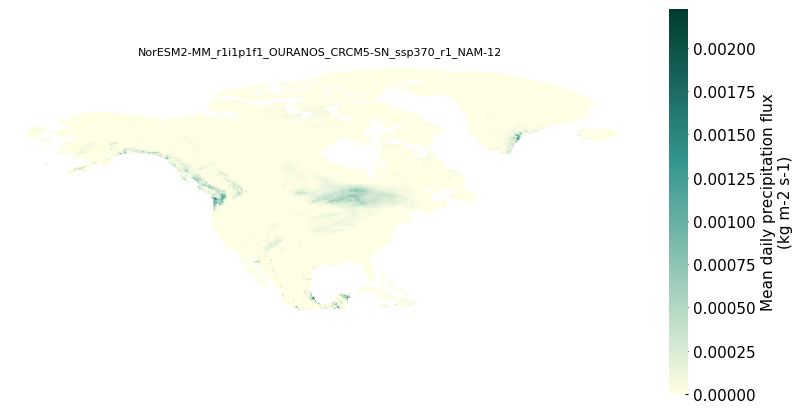

In [15]:
for var in ['tasmax','tasmin', 'pr']:
    for f in np.sort(glob.glob(f"{CONFIG['DQM']}staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/*/*/*/*/day/*/*{var}*")):
        ds=xr.open_zarr(f, decode_timedelta=False)
        ax=fg.gridmap(ds.isel(time=random.randint(0, len(ds.time))),plot_kw={ "cbar_kwargs": {"shrink": 0.5,}},fig_kw={'figsize':(10,10)}  )
        ax.set_extent([-179.95, -10, 10, 83.4 ], crs=ccrs.PlateCarree())
        ax.set_title(ds.attrs['cat:id'].replace('CMIP6_CORDEX_','').replace('_global',''), fontsize=8)


# Martin's plot 

2025-12-18 15:39:31 INFO     xscen.spatial   Loading longitude for more efficient subsetting.


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


2025-12-18 15:40:09 INFO     xscen.spatial   Loading longitude for more efficient subsetting.


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


2025-12-18 15:41:26 INFO     xscen.spatial   Loading longitude for more efficient subsetting.


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


2025-12-18 15:42:27 INFO     xscen.spatial   Loading longitude for more efficient subsetting.


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


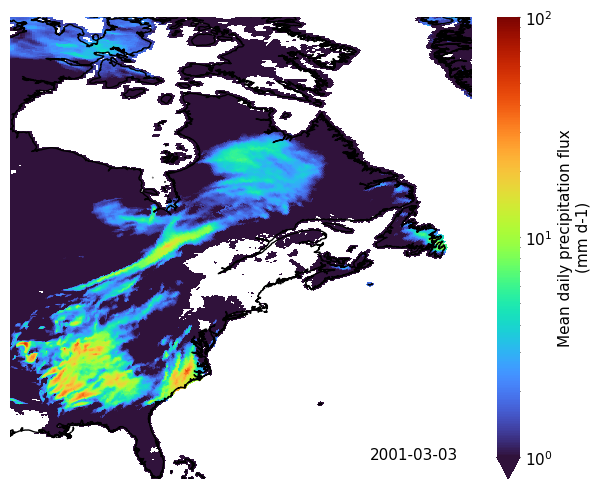

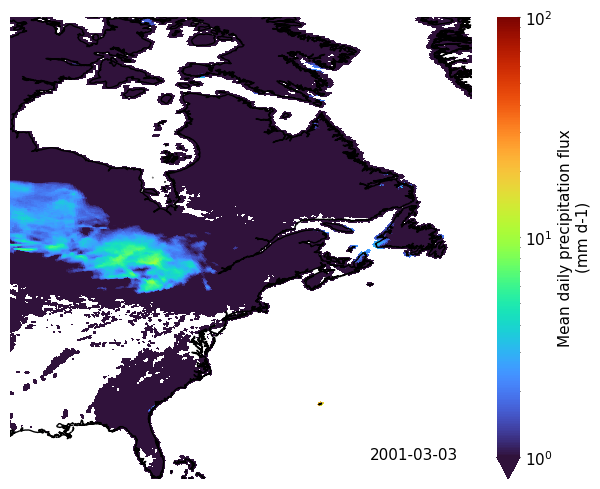

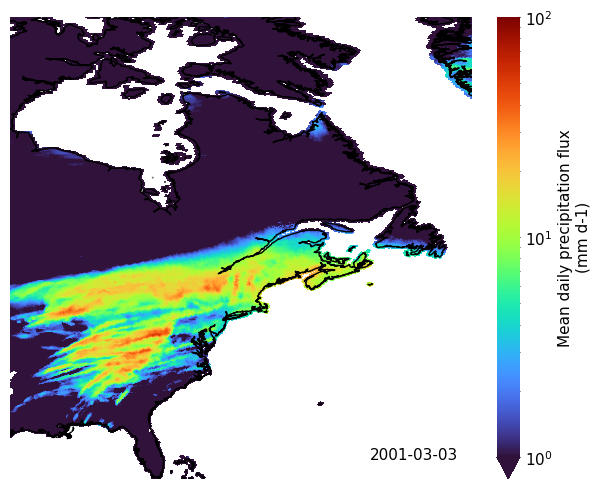

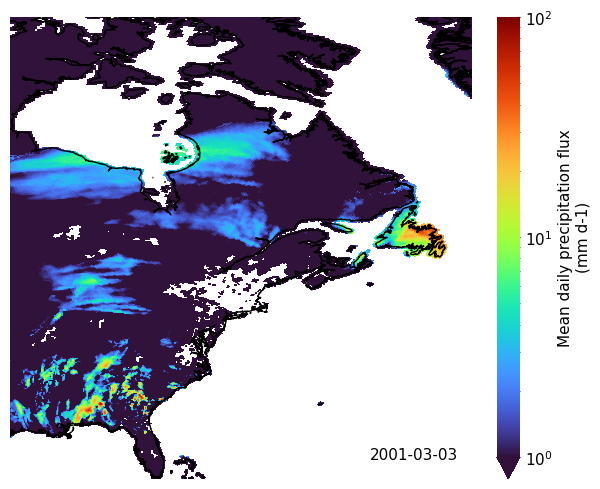

/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/dask/array/reductions.py:291: RuntimeWarning: All-NaN slice encountered


In [3]:
def fgplot_martin(ds):

    data = xs.spatial.subset(ds.pr,method='bbox', name='QC', lon_bnds=[-116, -50], lat_bnds=[25, 70])
    with xr.set_options(keep_attrs=True):
        data=xc.core.units.convert_units_to(data, 'mm/day', context='hydro')
    # fix xclim bug
    #data.attrs['long_name']= 'Precipitation'

    ax=fg.gridmap(data,
                  #ax=ax,
                  fig_kw=dict(figsize=(8, 6)),
                  plot_kw=dict(norm=LogNorm(vmin=1, vmax=100), cmap='turbo', 
                              cbar_kwargs=dict(orientation="vertical", fraction=0.046, pad=0.04)),
                  features=dict(coastline=dict(scale='10m', color='black', linewidth=1)),
                  projection=ccrs.PlateCarree(),
                  show_time=True,
                 )

    ax.set_xlim(-95, -50)
    ax.set_ylim(25, 70)

    return ax


for f in np.sort(glob.glob(f"{CONFIG['DQM']}staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/*/*/*/*/day/*/*pr*")):
    ds=xr.open_zarr(f, decode_timedelta=False)
    fgplot_martin(ds.sel(time='2001-03-03'))

# old stuff

In [11]:
import os
f"{os.environ['SLURM_TMPDIR']}"

'/localscratch/julavoie.53732095.0'

In [12]:

 

ds_input = xr.open_zarr('/scratch/julavoie/espo-workdir/CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12+NAM-C3+extracted.zarr', decode_timedelta=False)
display(ds_input)
ds_target = xr.open_zarr('/project/ctb-frigon/julavoie/ESPO/dec2025/reference/split_regions/NAM-C3_northC3_noleap.zarr.zip', decode_timedelta=False)
display(ds_target)

ds_regrid = xs.regrid_dataset(
    ds=ds_input,
    ds_grid=ds_target,
    #weights_location=f"/scratch/julavoie/weights/" 
)

# chunk time dim
ds_regrid = ds_regrid.chunk(
    xs.utils.translate_time_chunk({'time': '4year'},
                         xc.core.calendar.get_calendar(ds_regrid),
                         ds_regrid.time.size)
                           )
ds_regrid = ds_regrid.chunk(
    xs.utils.translate_time_chunk({'time': '4year'},
                         xc.core.calendar.get_calendar(ds_regrid),
                         ds_regrid.time.size)
                           )

display(ds_regrid)
xs.save_to_zarr(ds_regrid, f"{os.environ['SLURM_TMPDIR']}/regrid2.zarr")

<xarray.Dataset> Size: 363GB
Dimensions:  (time: 55152, rlat: 628, rlon: 655)
Coordinates:
    crs      |S1 1B ...
    lat      (rlat, rlon) float64 3MB dask.array<chunksize=(628, 655), meta=np.ndarray>
    lon      (rlat, rlon) float64 3MB dask.array<chunksize=(628, 655), meta=np.ndarray>
  * rlat     (rlat) float64 5kB -33.62 -33.52 -33.41 -33.3 ... 35.12 35.23 35.34
  * rlon     (rlon) float64 5kB -34.05 -33.94 -33.83 -33.72 ... 37.67 37.78 37.9
  * time     (time) datetime64[ns] 441kB 1950-01-01 1950-01-02 ... 2100-12-31
Data variables:
    dtr      (time, rlat, rlon) float32 91GB dask.array<chunksize=(365, 628, 655), meta=np.ndarray>
    mask     (rlat, rlon) float32 2MB dask.array<chunksize=(628, 655), meta=np.ndarray>
    pr       (time, rlat, rlon) float32 91GB dask.array<chunksize=(365, 628, 655), meta=np.ndarray>
    tasmax   (time, rlat, rlon) float32 91GB dask.array<chunksize=(365, 628, 655), meta=np.ndarray>
    tasmin   (time, rlat, rlon) float32 91GB dask.array<chunksize=(365, 628, 655), meta=np.ndarray>
Attributes: (12/55)
    Conventions:              CF-1.11
    NCO:                      netCDF Operators version 5.1.8 (Homepage = http...
    activity_id:              DD
    cat:_data_format_:        nc
    cat:activity:             CORDEX
    cat:date_end:             1950-12-31 23:00:00
    ...                       ...
    source_name:              CRCM5
    source_type:              ARCM
    title:                    CRMC5 output, model ran by Ouranos, prepared fo...
    tracking_id:              hdl:21.14100/9eaab31f-7c1d-492a-a1aa-a02579ae6c8c
    variable_id:              tasmax
    version_realization:      v1-r1

<xarray.Dataset> Size: 18GB
Dimensions:       (time: 10950, loc: 102701)
Coordinates:
    lat           (loc) float32 411kB dask.array<chunksize=(600,), meta=np.ndarray>
    lon           (loc) float32 411kB dask.array<chunksize=(600,), meta=np.ndarray>
    rlat          (loc) float32 411kB dask.array<chunksize=(600,), meta=np.ndarray>
    rlon          (loc) float32 411kB dask.array<chunksize=(600,), meta=np.ndarray>
    rotated_pole  int32 4B ...
  * time          (time) object 88kB 1991-01-01 00:00:00 ... 2020-12-31 00:00:00
Dimensions without coordinates: loc
Data variables:
    dtr           (time, loc) float32 4GB dask.array<chunksize=(10950, 600), meta=np.ndarray>
    pr            (time, loc) float32 4GB dask.array<chunksize=(10950, 600), meta=np.ndarray>
    tasmax        (time, loc) float32 4GB dask.array<chunksize=(10950, 600), meta=np.ndarray>
    tasmin        (time, loc) float32 4GB dask.array<chunksize=(10950, 600), meta=np.ndarray>
Attributes: (12/38)
    Conventions:             CF-1.8
    Remarks:                 Original variable names are following the conven...
    cat:_data_format_:       zarr
    cat:calendar:            noleap
    cat:date_end:            2024-12-31 23:00:00
    cat:date_start:          1980-01-01 00:00:00
    ...                      ...
    table_date:              2025-11-17
    table_id:                eccc
    terms_of_use:            Canadian Surface Reanalysis data users should ac...
    title:                   Canadian Surface Reanalysis (CaSR) / Réanalyse ...
    type:                    reconstruction
    version:                 v3.2

<xarray.Dataset> Size: 91GB
Dimensions:       (time: 55152, loc: 102701)
Coordinates:
    crs           |S1 1B ...
  * time          (time) datetime64[ns] 441kB 1950-01-01 ... 2100-12-31
    lat           (loc) float32 411kB dask.array<chunksize=(600,), meta=np.ndarray>
    lon           (loc) float32 411kB dask.array<chunksize=(600,), meta=np.ndarray>
    rlat          (loc) float32 411kB dask.array<chunksize=(600,), meta=np.ndarray>
    rlon          (loc) float32 411kB dask.array<chunksize=(600,), meta=np.ndarray>
    rotated_pole  int32 4B ...
  * loc           (loc) int64 822kB 0 1 2 3 4 ... 102697 102698 102699 102700
Data variables:
    dtr           (time, loc) float32 23GB dask.array<chunksize=(1461, 102701), meta=np.ndarray>
    pr            (time, loc) float32 23GB dask.array<chunksize=(1461, 102701), meta=np.ndarray>
    tasmax        (time, loc) float32 23GB dask.array<chunksize=(1461, 102701), meta=np.ndarray>
    tasmin        (time, loc) float32 23GB dask.array<chunksize=(1461, 102701), meta=np.ndarray>
Attributes: (12/56)
    Conventions:              CF-1.11
    NCO:                      netCDF Operators version 5.1.8 (Homepage = http...
    activity_id:              DD
    cat:_data_format_:        nc
    cat:activity:             CORDEX
    cat:date_end:             1950-12-31 23:00:00
    ...                       ...
    source_type:              ARCM
    title:                    CRMC5 output, model ran by Ouranos, prepared fo...
    tracking_id:              hdl:21.14100/9eaab31f-7c1d-492a-a1aa-a02579ae6c8c
    variable_id:              tasmax
    version_realization:      v1-r1
    regrid_method:            bilinear

2025-12-16 13:07:53 DEBUG    xscen.io        Writing ['dtr', 'pr', 'tasmax', 'tasmin'] for /localscratch/julavoie.53732095.0/regrid2.zarr.


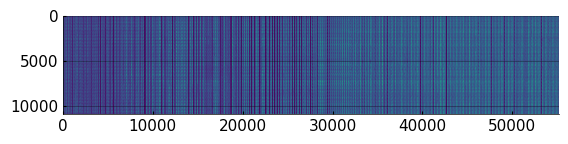

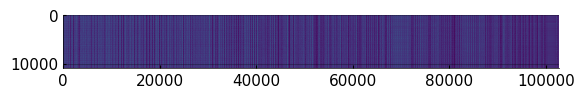

In [5]:
ds_targetS = xr.open_zarr('/project/ctb-frigon/julavoie/ESPO/dec2025/reference/split_regions/NAM-C3_southC3_noleap.zarr.zip', decode_timedelta=False)
ds_targetN = xr.open_zarr('/project/ctb-frigon/julavoie/ESPO/dec2025/reference/split_regions/NAM-C3_northC3_noleap.zarr.zip', decode_timedelta=False)

plt.imshow(ds_targetS.dtr.values)
plt.figure()
plt.imshow(ds_targetN.dtr.values)

In [8]:
ds_targetM = xr.open_zarr('/project/ctb-frigon/julavoie/ESPO/dec2025/reference/split_regions/NAM-C3_middleC3_noleap.zarr.zip', decode_timedelta=False)
display(ds_targetM)
display(ds_targetS)
display(ds_targetN)

<xarray.Dataset> Size: 21GB
Dimensions:       (time: 10950, loc: 118967)
Coordinates:
    lat           (loc) float32 476kB dask.array<chunksize=(600,), meta=np.ndarray>
    lon           (loc) float32 476kB dask.array<chunksize=(600,), meta=np.ndarray>
    rlat          (loc) float32 476kB dask.array<chunksize=(600,), meta=np.ndarray>
    rlon          (loc) float32 476kB dask.array<chunksize=(600,), meta=np.ndarray>
    rotated_pole  int32 4B ...
  * time          (time) object 88kB 1991-01-01 00:00:00 ... 2020-12-31 00:00:00
Dimensions without coordinates: loc
Data variables:
    dtr           (time, loc) float32 5GB dask.array<chunksize=(10950, 600), meta=np.ndarray>
    pr            (time, loc) float32 5GB dask.array<chunksize=(10950, 600), meta=np.ndarray>
    tasmax        (time, loc) float32 5GB dask.array<chunksize=(10950, 600), meta=np.ndarray>
    tasmin        (time, loc) float32 5GB dask.array<chunksize=(10950, 600), meta=np.ndarray>
Attributes: (12/38)
    Conventions:             CF-1.8
    Remarks:                 Original variable names are following the conven...
    cat:_data_format_:       zarr
    cat:calendar:            noleap
    cat:date_end:            2024-12-31 23:00:00
    cat:date_start:          1980-01-01 00:00:00
    ...                      ...
    table_date:              2025-11-17
    table_id:                eccc
    terms_of_use:            Canadian Surface Reanalysis data users should ac...
    title:                   Canadian Surface Reanalysis (CaSR) / Réanalyse ...
    type:                    reconstruction
    version:                 v3.2

<xarray.Dataset> Size: 10GB
Dimensions:       (time: 10950, loc: 55187)
Coordinates:
    lat           (loc) float32 221kB dask.array<chunksize=(600,), meta=np.ndarray>
    lon           (loc) float32 221kB dask.array<chunksize=(600,), meta=np.ndarray>
    rlat          (loc) float32 221kB dask.array<chunksize=(600,), meta=np.ndarray>
    rlon          (loc) float32 221kB dask.array<chunksize=(600,), meta=np.ndarray>
    rotated_pole  int32 4B ...
  * time          (time) object 88kB 1991-01-01 00:00:00 ... 2020-12-31 00:00:00
Dimensions without coordinates: loc
Data variables:
    dtr           (time, loc) float32 2GB dask.array<chunksize=(10950, 600), meta=np.ndarray>
    pr            (time, loc) float32 2GB dask.array<chunksize=(10950, 600), meta=np.ndarray>
    tasmax        (time, loc) float32 2GB dask.array<chunksize=(10950, 600), meta=np.ndarray>
    tasmin        (time, loc) float32 2GB dask.array<chunksize=(10950, 600), meta=np.ndarray>
Attributes: (12/38)
    Conventions:             CF-1.8
    Remarks:                 Original variable names are following the conven...
    cat:_data_format_:       zarr
    cat:calendar:            noleap
    cat:date_end:            2024-12-31 23:00:00
    cat:date_start:          1980-01-01 00:00:00
    ...                      ...
    table_date:              2025-11-17
    table_id:                eccc
    terms_of_use:            Canadian Surface Reanalysis data users should ac...
    title:                   Canadian Surface Reanalysis (CaSR) / Réanalyse ...
    type:                    reconstruction
    version:                 v3.2

<xarray.Dataset> Size: 18GB
Dimensions:       (time: 10950, loc: 102701)
Coordinates:
    lat           (loc) float32 411kB dask.array<chunksize=(600,), meta=np.ndarray>
    lon           (loc) float32 411kB dask.array<chunksize=(600,), meta=np.ndarray>
    rlat          (loc) float32 411kB dask.array<chunksize=(600,), meta=np.ndarray>
    rlon          (loc) float32 411kB dask.array<chunksize=(600,), meta=np.ndarray>
    rotated_pole  int32 4B ...
  * time          (time) object 88kB 1991-01-01 00:00:00 ... 2020-12-31 00:00:00
Dimensions without coordinates: loc
Data variables:
    dtr           (time, loc) float32 4GB dask.array<chunksize=(10950, 600), meta=np.ndarray>
    pr            (time, loc) float32 4GB dask.array<chunksize=(10950, 600), meta=np.ndarray>
    tasmax        (time, loc) float32 4GB dask.array<chunksize=(10950, 600), meta=np.ndarray>
    tasmin        (time, loc) float32 4GB dask.array<chunksize=(10950, 600), meta=np.ndarray>
Attributes: (12/38)
    Conventions:             CF-1.8
    Remarks:                 Original variable names are following the conven...
    cat:_data_format_:       zarr
    cat:calendar:            noleap
    cat:date_end:            2024-12-31 23:00:00
    cat:date_start:          1980-01-01 00:00:00
    ...                      ...
    table_date:              2025-11-17
    table_id:                eccc
    terms_of_use:            Canadian Surface Reanalysis data users should ac...
    title:                   Canadian Surface Reanalysis (CaSR) / Réanalyse ...
    type:                    reconstruction
    version:                 v3.2

In [ ]:
cat = xs.DataCatalog(CONFIG['extraction']['simulation']['search_data_catalogs']['data_catalogs'][0])

In [ ]:
ds_raw=cat.search(
    processing_level= 'raw',
    experiment= 'historical',
    source= 'CRCM5-SN',
    driving_model= 'MPI-ESM1-2-LR',
    driving_member= 'r1i1p1f1',
    variable='pr',
    member= 'r1').to_dataset()
# to make it work with figanos
ds_raw=ds_raw.rename({'crs':'rotated_pole'})
ds_raw

In [ ]:
def plot_martin(ds):
    
    # Sélectionner la région
    lon_bnds = [-116, -50]
    lat_bnds = [25, 70]
    
    data = xs.spatial.subset(ds.pr,method='bbox', name='QC', lon_bnds=lon_bnds, lat_bnds=lat_bnds)
    data=xc.core.units.convert_units_to(data, 'mm/day', context='hydro')
    

    dt = datetime.fromisoformat(str(data.time.values[0])[:26])
    date_clean = dt.strftime("%Y-%m-%d")

    # Créer une projection cartographique
    projection = ccrs.PlateCarree()

    # Initialiser la figure et les axes
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': projection})

    # Afficher la variable
    p = ax.pcolormesh(data['lon'], data['lat'], data.squeeze(), norm=LogNorm(vmin=1, vmax=100), cmap='turbo')

    ax.set_xlim(-95, -50)
    ax.set_ylim(25, 70)

    # Ajouter les lignes de côtes
    ax.coastlines(resolution='10m', color='black', linewidth=1)
    plt.colorbar(p,orientation="vertical", label="(mm/d)", fraction=0.046, pad=0.04)


def fgplot_martin(ds):

    data = xs.spatial.subset(ds.pr,method='bbox', name='QC', lon_bnds=[-116, -50], lat_bnds=[25, 70])
    with xr.set_options(keep_attrs=True):
        data=xc.core.units.convert_units_to(data, 'mm/day', context='hydro')
    # fix xclim bug
    #data.attrs['long_name']= 'Precipitation'

    ax=fg.gridmap(data,
                  #ax=ax,
                  fig_kw=dict(figsize=(8, 6)),
                  plot_kw=dict(norm=LogNorm(vmin=1, vmax=100), cmap='turbo', 
                              cbar_kwargs=dict(orientation="vertical", fraction=0.046, pad=0.04)),
                  features=dict(coastline=dict(scale='10m', color='black', linewidth=1)),
                  projection=ccrs.PlateCarree(),
                  show_time=True,
                 )

    ax.set_xlim(-95, -50)
    ax.set_ylim(25, 70)

    return ax


plot_martin(ds_raw.sel(time='2001-03-03'))
fgplot_martin(ds_raw.sel(time='2001-03-03'))

In [ ]:
ds_adj= xr.open_zarr(f"{CONFIG['DQM']}/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/MPI-ESM1-2-LR/r1i1p1f1/OURANOS/CRCM5-SN/day/pr/pr_day_ESPO6_v20_CaSRv31+CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1951-2100.zarr.zip")
ax=fgplot_martin(ds_adj.sel(time='2001-03-03'))
ax.set_title("LOESS f20n1d0tri")

ds_adj= xr.open_zarr(f"{CONFIG['DQM']}/loessf20n1d1tri/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/MPI-ESM1-2-LR/r1i1p1f1/OURANOS/CRCM5-SN/day/pr/pr_day_ESPO6_v20_CaSRv31+CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1951-2100.zarr.zip")
ax=fgplot_martin(ds_adj.sel(time='2001-03-03'))
ax.set_title("LOESS loessf28n1d0tri ")


ds_adj= xr.open_zarr(f"{CONFIG['DQM']}/loessf28n1d0tri/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/MPI-ESM1-2-LR/r1i1p1f1/OURANOS/CRCM5-SN/day/pr/pr_day_ESPO6_v20_CaSRv31+CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1951-2100.zarr.zip")
ax=fgplot_martin(ds_adj.sel(time='2001-03-03'))
ax.set_title("LOESS loessf28n1d0tri ")

ds_adj= xr.open_zarr(f"{CONFIG['DQM']}/loessf28n1d1tri/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/MPI-ESM1-2-LR/r1i1p1f1/OURANOS/CRCM5-SN/day/pr/pr_day_ESPO6_v20_CaSRv31+CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1951-2100.zarr.zip")
ax=fgplot_martin(ds_adj.sel(time='2001-03-03'))
ax.set_title("LOESS loessf28n1d1tri ")

ds_adj= xr.open_zarr(f"{CONFIG['DQM']}/loessf20n1d1gau/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/MPI-ESM1-2-LR/r1i1p1f1/OURANOS/CRCM5-SN/day/pr/pr_day_ESPO6_v20_CaSRv31+CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1951-2100.zarr.zip")
ax=fgplot_martin(ds_adj.sel(time='2001-03-03'))
ax.set_title("LOESS loessf20n1d1gau ")


ds_adj= xr.open_zarr(f"{CONFIG['DQM']}/loessf33n1d0tri/staging/simulation/biasadjusted/ESPO6_v20/CMIP6/CORDEX/NAM-C3/MPI-ESM1-2-LR/r1i1p1f1/OURANOS/CRCM5-SN/day/pr/pr_day_ESPO6_v20_CaSRv31+CMIP6_CORDEX_MPI-ESM1-2-LR_r1i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12_NAM-C3_1951-2100.zarr.zip")
ax=fgplot_martin(ds_adj.sel(time='2001-03-03'))
ax.set_title("LOESS loessf33n1d0tri ")